# 03 – Transportation Pricing

This notebook applies the transportation pricing methodology to calculate estimated transportation costs across:

- Shipping Group × Province  
- Shipping Group × City  
- Product × Province  

The pricing model combines product capacity, loaded weight, transportation distance, and configurable commercial parameters.

### Import

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sys.path.append("../")

from src.transportation_cost_calculator import (
    calculate_final_transportation_cost
)

### Load Product Data

In [2]:
file_path = "../data/raw/main.xlsx"

df_data = pd.read_excel(
    file_path,
    sheet_name="Data"
)

df_data = df_data.rename(columns={
    "عنوان گروه ارسال کالا": "shipping_group",
    "کد گروه ارسال کالا": "shipping_group_code",
    "کد کالا": "product_code",
    "نام کالا": "product_name",
    "گروه محصول": "product_group",
    "حجم": "volume_m3",
    "تناژ": "weight_ton"
})

df_data = df_data[[
    "shipping_group",
    "shipping_group_code",
    "product_code",
    "product_name",
    "product_group",
    "volume_m3",
    "weight_ton"
]].copy()

### Load Location Data

In [3]:
df_loc = pd.read_excel(
    file_path,
    sheet_name="Loc"
)

df_loc = df_loc.rename(columns={
    "منطقه": "region",
    "استان مقصد": "dest_province",
    "شهر مقصد": "dest_city",
    "KM": "km"
})

df_loc["km"] = pd.to_numeric(
    df_loc["km"],
    errors="coerce"
)

df_loc = df_loc.dropna(
    subset=["km"]
)

### Capacity Calculation

In [4]:
VOLUME_CAPACITY = 18.5
WEIGHT_CAPACITY = 2.0

df_data["volume_m3"] = pd.to_numeric(
    df_data["volume_m3"],
    errors="coerce"
).fillna(0)

df_data["weight_ton"] = pd.to_numeric(
    df_data["weight_ton"],
    errors="coerce"
).fillna(0)

df_data = df_data[
    ~(
        (df_data["volume_m3"] <= 0) &
        (df_data["weight_ton"] <= 0)
    )
].copy()

df_data["quantity_by_volume"] = np.where(
    df_data["volume_m3"] > 0,
    VOLUME_CAPACITY /
    df_data["volume_m3"],
    np.inf
)

df_data["quantity_by_weight"] = np.where(
    df_data["weight_ton"] > 0,
    WEIGHT_CAPACITY /
    df_data["weight_ton"],
    np.inf
)

df_data["final_qty"] = np.minimum(
    df_data["quantity_by_volume"],
    df_data["quantity_by_weight"]
)

df_data["final_qty"] = df_data[
    "final_qty"
].replace(
    np.inf,
    np.nan
)

df_data["loaded_weight_ton"] = (
    df_data["final_qty"] *
    df_data["weight_ton"]
).clip(
    upper=WEIGHT_CAPACITY
)

### Province Distance

In [5]:
prov_km = (
    df_loc
    .groupby(
        ["dest_province", "region"],
        as_index=False
    )
    .agg(
        km_median=("km", "median")
    )
)

### City Distance

In [6]:
city_km = (
    df_loc[
        [
            "dest_province",
            "dest_city",
            "region",
            "km"
        ]
    ]
    .drop_duplicates()
)

### Shipping Group Summary

In [7]:
group_stats = (
    df_data
    .groupby(
        [
            "shipping_group",
            "shipping_group_code"
        ],
        as_index=False
    )
    .agg(
        n_products=("product_code", "count"),
        median_loaded_weight=(
            "loaded_weight_ton",
            "median"
        ),
        max_loaded_weight=(
            "loaded_weight_ton",
            "max"
        )
    )
)

group_stats.head()

,shipping_group,shipping_group_code,n_products,median_loaded_weight,max_loaded_weight
0,"60 , 50 , 40 GSS0",241128,2,1.0,2.0
1,9000 IN & OD,241101,53,2.0,2.0
2,AV Vid & Aud,241011,137,0.0,2.0
3,FDP Table,241015,208,0.0,2.0
4,Handsfree,241504,6,0.0,0.0


### Commercial Parameters

In [8]:
RATE_PER_TON_KM = 1.0
INSURANCE = 0.0
RAHDARI_PCT = 0.0
LOADING_PCT = 0.0

### Group × Province

In [9]:
df_group_prov = (
    group_stats
    .merge(
        prov_km,
        how="cross"
    )
)

df_group_prov["total_cost"] = (
    df_group_prov.apply(
        lambda row:
        calculate_final_transportation_cost(
            row["median_loaded_weight"],
            row["km_median"],
            RATE_PER_TON_KM,
            INSURANCE,
            RAHDARI_PCT,
            LOADING_PCT
        ),
        axis=1
    )
)

### Group × City

In [10]:
df_group_city = (
    group_stats
    .merge(
        city_km,
        how="cross"
    )
)

df_group_city["total_cost"] = (
    df_group_city.apply(
        lambda row:
        calculate_final_transportation_cost(
            row["median_loaded_weight"],
            row["km"],
            RATE_PER_TON_KM,
            INSURANCE,
            RAHDARI_PCT,
            LOADING_PCT
        ),
        axis=1
    )
)

### Product × Province


In [11]:
df_prod_prov = (
    df_data
    .merge(
        prov_km,
        how="cross"
    )
)

df_prod_prov["total_cost"] = (
    df_prod_prov.apply(
        lambda row:
        calculate_final_transportation_cost(
            row["loaded_weight_ton"],
            row["km_median"],
            RATE_PER_TON_KM,
            INSURANCE,
            RAHDARI_PCT,
            LOADING_PCT
        ),
        axis=1
    )
)

### Save Results

In [12]:
df_group_prov.to_csv(
    "../results/tables/shipping_group_province_pricing.csv",
    index=False
)

df_group_city.to_csv(
    "../results/tables/shipping_group_city_pricing.csv",
    index=False
)

df_prod_prov.to_csv(
    "../results/tables/product_province_pricing.csv",
    index=False
)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
FIGURES_DIR = Path("../results")  
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", font_scale=1.1)

### 1. Limiting Factor Distribution Python

۱. توزیع Limiting Factor Python

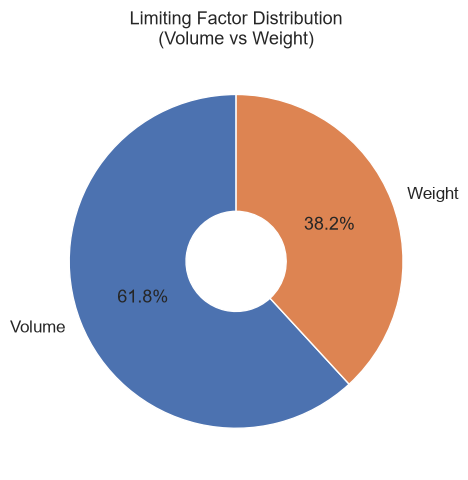

In [25]:
fig, ax = plt.subplots(figsize=(7, 5))

counts = df_products["limiting_factor"].value_counts()
colors = ["#4C72B0", "#DD8452"]

ax.pie(
    counts,
    labels=counts.index.str.title(),
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    wedgeprops=dict(width=0.7)
)

ax.set_title("Limiting Factor Distribution\n(Volume vs Weight)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_limiting_factor_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### 2. Relationship between distance and cost (Scatter)
۲. رابطه فاصله و هزینه (Scatter)

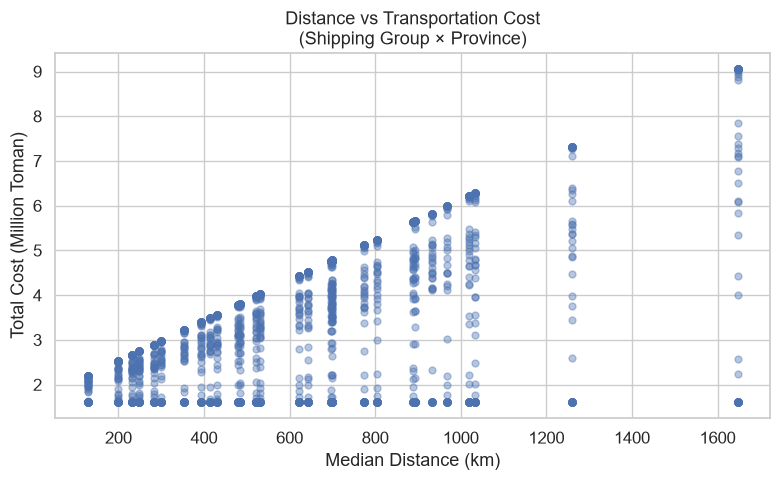

In [26]:
fig, ax = plt.subplots(figsize=(8, 5))

sample = df_group_prov.sample(n=min(2000, len(df_group_prov)), random_state=42)

ax.scatter(
    sample["km_median"],
    sample["total_cost_toman"] / 1_000_000,   # میلیون تومان
    alpha=0.4,
    s=25,
    color="#4C72B0"
)

ax.set_xlabel("Median Distance (km)")
ax.set_ylabel("Total Cost (Million Toman)")
ax.set_title("Distance vs Transportation Cost\n(Shipping Group × Province)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_distance_vs_cost.png", dpi=150, bbox_inches="tight")
plt.show()

### 3. Average cost for several frequently occurring provinces
۳. میانگین هزینه چند استان پرتکرار

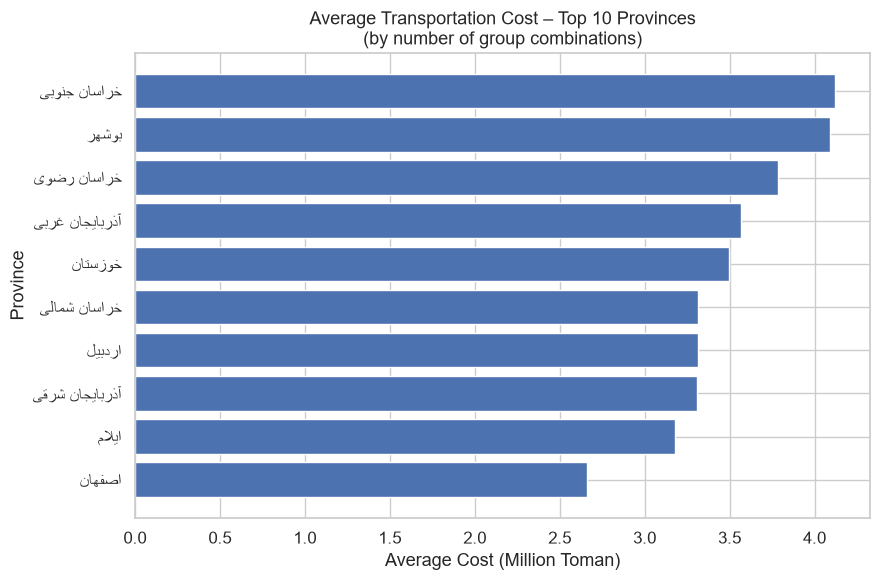

In [27]:
# انتخاب ۱۰ استان با بیشترین تعداد ترکیب (یا می‌تونی دستی لیست کنی)
top_provinces = (
    df_group_prov
    .groupby("dest_province")["total_cost_toman"]
    .agg(["mean", "count"])
    .sort_values("count", ascending=False)
    .head(10)
    .sort_values("mean", ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 6))

ax.barh(
    top_provinces.index,
    top_provinces["mean"] / 1_000_000,
    color="#4C72B0"
)

ax.set_xlabel("Average Cost (Million Toman)")
ax.set_ylabel("Province")
ax.set_title("Average Transportation Cost – Top 10 Provinces\n(by number of group combinations)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_avg_cost_by_province.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
import sys
from pathlib import Path
src_path = Path("../src").resolve()
sys.path.insert(0, str(src_path))

print("src path:", src_path)
print("exists:", src_path.exists())

import importlib
import transportation_cost_calculator as tcc
importlib.reload(tcc)

print("DATA_PATH:", tcc.DATA_PATH)
print("Exists:", tcc.DATA_PATH.exists())

src path: \\GLCHQ-FILESRV01\GLCHQ-Home$\M.Aram\me\Transportation-Pricing-Cost-Optimization\src
exists: True
DATA_PATH: \\GLCHQ-FILESRV01\GLCHQ-Home$\M.Aram\me\Transportation-Pricing-Cost-Optimization\data\raw\main.xlsx
Exists: True


In [22]:
print(tcc.DATA_PATH)
print(tcc.DATA_PATH.exists())

\\GLCHQ-FILESRV01\GLCHQ-Home$\M.Aram\me\Transportation-Pricing-Cost-Optimization\data\raw\main.xlsx
True


In [23]:
results = tcc.run()

df_products = results["products"]
df_groups = results["groups"]
df_group_prov = results["group_province"]
df_group_city = results["group_city"]
df_prod_prov = results["product_province"]

print("OK")
print("Products:", df_products.shape)

Products : 13512
Groups   : 136
Provinces: 29
Cities   : 304
Saved: 01_Product_Capacity.xlsx
Saved: 02_Group_Summary.xlsx
Saved: 03_Group_x_Province.xlsx  shape=(3944, 10)
Saved: 04_Group_x_City.xlsx  shape=(41344, 11)
Saved: 05_Product_x_Province_FULL.csv  shape=(391848, 15)
Saved: 05_Product_x_Province_Sample.xlsx

Done.
OK
Products: (13512, 10)
